**Data Engineering & Exploration.**

Libaries

In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

**1.Data Collection**

The dataset was collected in CSV format from the Kaggle platform.

In [ ]:

df = pd.read_csv("/content/user_personalized_features.csv")

print(df.head())
print(df.columns)
print(df.info())

   Unnamed: 0 User_ID  Age  Gender  Location  Income   Interests  \
0           0      #1   56    Male  Suburban   38037      Sports   
1           1      #2   46  Female     Rural  103986  Technology   
2           2      #3   32  Female  Suburban  101942      Sports   
3           3      #4   60  Female  Suburban   71612     Fashion   
4           4      #5   25    Male  Suburban   49725      Travel   

   Last_Login_Days_Ago  Purchase_Frequency  Average_Order_Value  \
0                    5                   7                   18   
1                   15                   7                  118   
2                   28                   1                  146   
3                   18                   3                  163   
4                    2                   5                  141   

   Total_Spending Product_Category_Preference  Time_Spent_on_Site_Minutes  \
0            2546                       Books                         584   
1             320                 

**2.Data Preprocessing**

i ) Handle Missing Values

In [ ]:

#  BEFORE Handling Missing Values
print(" BEFORE")
print(df.isnull().sum())

# Numerical columns → fill with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# AFTER Handling Missing Values

print("\n AFTER")
print(df.isnull().sum())

 BEFORE
Unnamed: 0                     0
User_ID                        0
Age                            0
Gender                         0
Location                       0
Income                         0
Interests                      0
Last_Login_Days_Ago            0
Purchase_Frequency             0
Average_Order_Value            0
Total_Spending                 0
Product_Category_Preference    0
Time_Spent_on_Site_Minutes     0
Pages_Viewed                   0
Newsletter_Subscription        0
dtype: int64

 AFTER
Unnamed: 0                     0
User_ID                        0
Age                            0
Gender                         0
Location                       0
Income                         0
Interests                      0
Last_Login_Days_Ago            0
Purchase_Frequency             0
Average_Order_Value            0
Total_Spending                 0
Product_Category_Preference    0
Time_Spent_on_Site_Minutes     0
Pages_Viewed                   0
Newsletter_Sub

ii ) Remove Duplicates

In [ ]:
#  BEFORE Removing Duplicates
print(" BEFORE")
print("Shape:", df.shape)

duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

# Remove Duplicates

df = df.drop_duplicates()

#  AFTER Removing Duplicates
print("\n AFTER")
print("Shape:", df.shape)

duplicate_count_after = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count_after)

 BEFORE
Shape: (1000, 15)
Duplicate Rows: 0

 AFTER
Shape: (1000, 15)
Duplicate Rows: 0


iii ) Normalize Numerical Features

In [ ]:

#  BEFORE Normalization
print(" BEFORE NORMALIZATION")
print(df[num_cols].head())

# Apply Min-Max Normalization

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# AFTER Normalization
print("\n AFTER NORMALIZATION")
print(df[num_cols].head())

 BEFORE NORMALIZATION
   Unnamed: 0  Age  Income  Last_Login_Days_Ago  Purchase_Frequency  \
0           0   56   38037                    5                   7   
1           1   46  103986                   15                   7   
2           2   32  101942                   28                   1   
3           3   60   71612                   18                   3   
4           4   25   49725                    2                   5   

   Average_Order_Value  Total_Spending  Time_Spent_on_Site_Minutes  \
0                   18            2546                         584   
1                  118             320                         432   
2                  146            3766                         306   
3                  163            4377                         527   
4                  141            4502                          53   

   Pages_Viewed  
0            38  
1            40  
2             1  
3            29  
4            10  

 AFTER NORMALIZATION


iv ) Encode Categorical Variables

In [ ]:

#  BEFORE Encoding
print("BEFORE ENCODING")
print(df[cat_cols].head())

# Apply One-Hot Encoding

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

#  AFTER Encoding
print("\n AFTER ENCODING")
print(df_encoded.head())

BEFORE ENCODING
  User_ID  Gender  Location   Interests Product_Category_Preference
0      #1    Male  Suburban      Sports                       Books
1      #2  Female     Rural  Technology                 Electronics
2      #3  Female  Suburban      Sports                     Apparel
3      #4  Female  Suburban     Fashion                     Apparel
4      #5    Male  Suburban      Travel             Health & Beauty

 AFTER ENCODING
   Unnamed: 0       Age    Income  Last_Login_Days_Ago  Purchase_Frequency  \
0    0.000000  0.826087  0.137770             0.142857            0.777778   
1    0.001001  0.608696  0.645867             0.500000            0.777778   
2    0.002002  0.304348  0.630120             0.964286            0.111111   
3    0.003003  0.913043  0.396445             0.607143            0.333333   
4    0.004004  0.152174  0.227819             0.035714            0.555556   

   Average_Order_Value  Total_Spending  Time_Spent_on_Site_Minutes  \
0             0.0423

**3.Feature Engineering**

i ) User-Product Interaction Matrix

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

interaction = pd.pivot_table(
    df,
    index='user_id',
    columns='product_category_preference',
    aggfunc='size',
    fill_value=0
)

print(interaction.head())

product_category_preference  Apparel  Books  Electronics  Health & Beauty  \
user_id                                                                     
#1                                 0      1            0                0   
#10                                0      0            1                0   
#100                               1      0            0                0   
#1000                              0      0            0                1   
#101                               0      0            0                1   

product_category_preference  Home & Kitchen  
user_id                                      
#1                                        0  
#10                                       0  
#100                                      0  
#1000                                     0  
#101                                      0  


ii ) Generate product similarity features

In [ ]:
# Transpose → products as rows
product_similarity = cosine_similarity(interaction.T)

# Convert to DataFrame
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=interaction.columns,
    columns=interaction.columns
)

print("\n Product Similarity Matrix")
print(product_similarity_df.head())




 Product Similarity Matrix
product_category_preference  Apparel  Books  Electronics  Health & Beauty  \
product_category_preference                                                 
Apparel                          1.0    0.0          0.0              0.0   
Books                            0.0    1.0          0.0              0.0   
Electronics                      0.0    0.0          1.0              0.0   
Health & Beauty                  0.0    0.0          0.0              1.0   
Home & Kitchen                   0.0    0.0          0.0              0.0   

product_category_preference  Home & Kitchen  
product_category_preference                  
Apparel                                 0.0  
Books                                   0.0  
Electronics                             0.0  
Health & Beauty                         0.0  
Home & Kitchen                          1.0  


iii ) Create User Behavior Metrics

In [ ]:

# Select User Behavior Metrics

user_behavior = df[[
    'user_id',
    'purchase_frequency',
    'average_order_value',
    'total_spending',
    'time_spent_on_site_minutes',
    'pages_viewed',
    'last_login_days_ago'
]]


print(" User Behavior Metrics")
print(user_behavior.head())


 User Behavior Metrics
  user_id  purchase_frequency  average_order_value  total_spending  \
0      #1            0.777778             0.042328        0.498056   
1      #2            0.777778             0.571429        0.042562   
2      #3            0.111111             0.719577        0.747698   
3      #4            0.333333             0.809524        0.872724   
4      #5            0.555556             0.693122        0.898302   

   time_spent_on_site_minutes  pages_viewed  last_login_days_ago  
0                    0.974874      0.770833             0.142857  
1                    0.720268      0.812500             0.500000  
2                    0.509213      0.000000             0.964286  
3                    0.879397      0.583333             0.607143  
4                    0.085427      0.187500             0.035714  


4.**Exploratory Data Analysis (EDA)**

i ) Identify most viewed products


SECTION 1 — MOST VIEWED / PREFERRED PRODUCTS
Product_Category_Preference
Apparel            218
Electronics        209
Books              198
Home & Kitchen     189
Health & Beauty    186


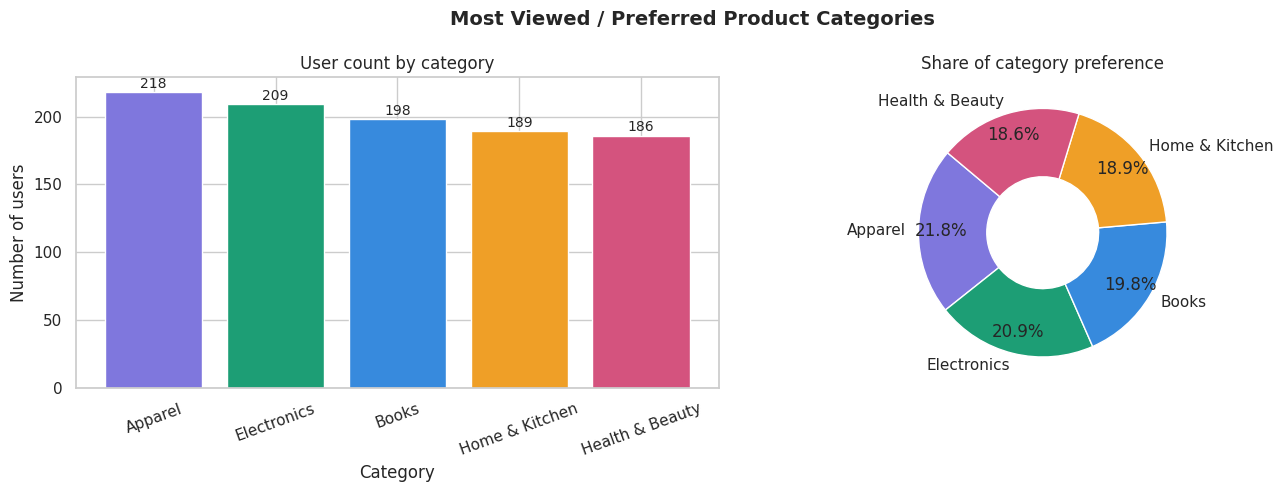

 most_viewed_products


In [6]:
print("\n" + "=" * 60)
print("SECTION 1 — MOST VIEWED / PREFERRED PRODUCTS")
print("=" * 60)

cat_counts = df["Product_Category_Preference"].value_counts()
print(cat_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Most Viewed / Preferred Product Categories", fontsize=14, fontweight="bold")

# Bar chart — user count
axes[0].bar(cat_counts.index, cat_counts.values, color=PALETTE, edgecolor="white")
axes[0].set_title("User count by category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Number of users")
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(axes[0].patches, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%",
            colors=PALETTE, startangle=140, pctdistance=0.82,
            wedgeprops=dict(width=0.55))
axes[1].set_title("Share of category preference")

plt.tight_layout()
#plt.savefig("plot1_most_viewed_products.png", dpi=150, bbox_inches="tight")
plt.show()
print(" most_viewed_products")

ii ) Analyze top categories


SECTION 2 — TOP CATEGORIES ANALYSIS

Total spending by category:
Product_Category_Preference
Apparel            568820
Home & Kitchen     516217
Electronics        502030
Health & Beauty    487525
Books              478365
Name: Total_Spending, dtype: int64

Avg order value by category:
Product_Category_Preference
Electronics        109.15
Health & Beauty    104.39
Home & Kitchen     103.60
Books              102.68
Apparel            100.46
Name: Average_Order_Value, dtype: float64

Avg time on site (mins) by category:
Product_Category_Preference
Health & Beauty    322.6
Electronics        298.8
Books              298.0
Home & Kitchen     296.0
Apparel            275.1
Name: Time_Spent_on_Site_Minutes, dtype: float64

Avg pages viewed by category:
Product_Category_Preference
Apparel            25.4
Home & Kitchen     25.1
Health & Beauty    24.5
Books              24.4
Electronics        22.5
Name: Pages_Viewed, dtype: float64


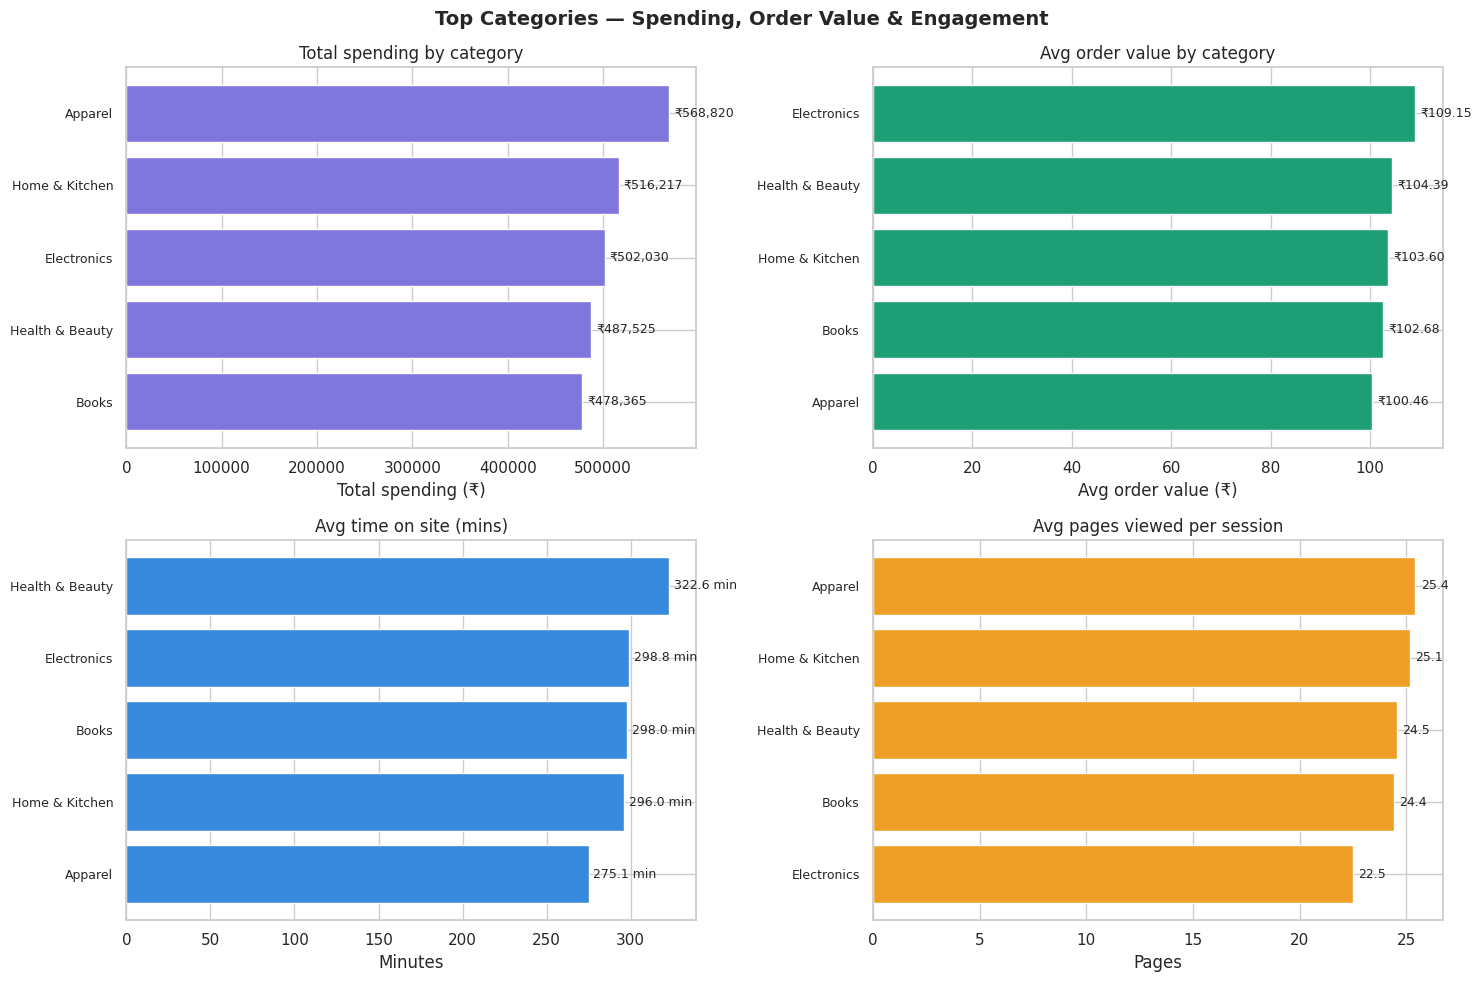

top_categories


In [7]:
print("\n" + "=" * 60)
print("SECTION 2 — TOP CATEGORIES ANALYSIS")
print("=" * 60)

cat_spend   = df.groupby("Product_Category_Preference")["Total_Spending"].sum().sort_values(ascending=False)
cat_aov     = df.groupby("Product_Category_Preference")["Average_Order_Value"].mean().sort_values(ascending=False)
cat_time    = df.groupby("Product_Category_Preference")["Time_Spent_on_Site_Minutes"].mean().sort_values(ascending=False)
cat_pages   = df.groupby("Product_Category_Preference")["Pages_Viewed"].mean().sort_values(ascending=False)

print(f"\nTotal spending by category:\n{cat_spend.round(0)}")
print(f"\nAvg order value by category:\n{cat_aov.round(2)}")
print(f"\nAvg time on site (mins) by category:\n{cat_time.round(1)}")
print(f"\nAvg pages viewed by category:\n{cat_pages.round(1)}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Top Categories — Spending, Order Value & Engagement", fontsize=14, fontweight="bold")

def bar_h(ax, series, title, xlabel, color="#7F77DD", fmt=None):
    bars = ax.barh(series.index[::-1], series.values[::-1], color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.tick_params(axis="y", labelsize=9)
    for bar, val in zip(bars, series.values[::-1]):
        label = fmt(val) if fmt else f"{val:,.1f}"
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                label, va="center", fontsize=9)

bar_h(axes[0, 0], cat_spend,  "Total spending by category", "Total spending (₹)",
      color="#7F77DD", fmt=lambda v: f"₹{v:,.0f}")
bar_h(axes[0, 1], cat_aov,    "Avg order value by category", "Avg order value (₹)",
      color="#1D9E75", fmt=lambda v: f"₹{v:.2f}")
bar_h(axes[1, 0], cat_time,   "Avg time on site (mins)", "Minutes",
      color="#378ADD", fmt=lambda v: f"{v:.1f} min")
bar_h(axes[1, 1], cat_pages,  "Avg pages viewed per session", "Pages",
      color="#EF9F27", fmt=lambda v: f"{v:.1f}")

plt.tight_layout()
#plt.savefig("plot2_top_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print("top_categories")

iii ) Study purchase patterns


SECTION 3 — PURCHASE PATTERNS

Purchase frequency distribution:
count    1000.00
mean        4.63
std         2.84
min         0.00
25%         2.00
50%         5.00
75%         7.00
max         9.00
Name: Purchase_Frequency, dtype: float64

Frequency segments:
freq_segment
Low (1–2)      195
Mid (3–5)      309
High (6–10)    411
Name: count, dtype: int64

Top interests:
Interests
Sports        213
Fashion       209
Travel        196
Food          196
Technology    186
Name: count, dtype: int64

Avg spending by newsletter subscription:
Newsletter_Subscription
False    2563.70
True     2542.51
Name: Total_Spending, dtype: float64


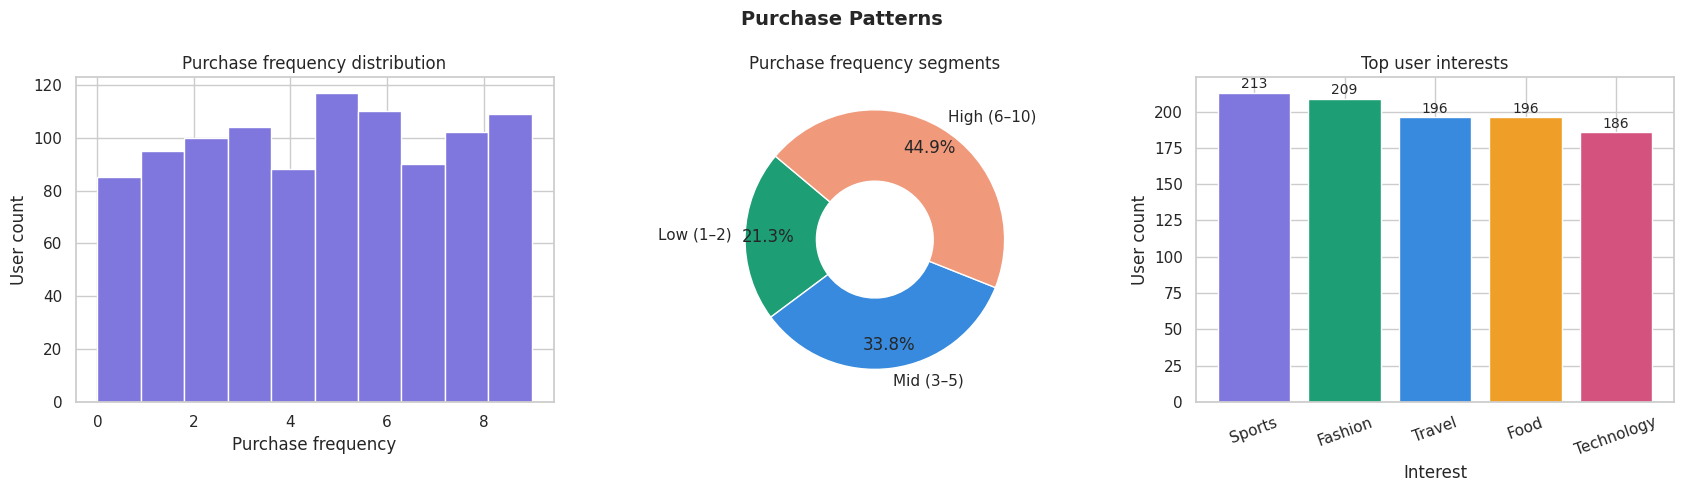

purchase_patterns


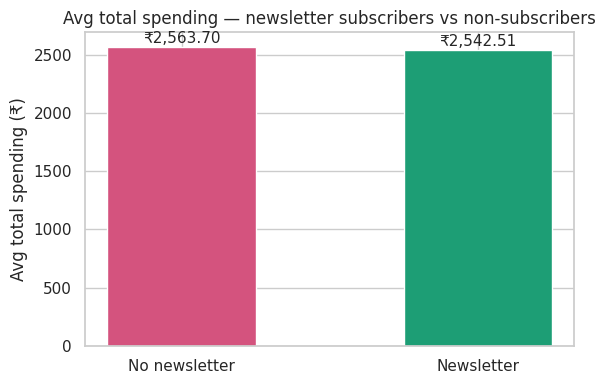

newsletter_spending

CORRELATION HEATMAP — NUMERIC FEATURES
                             Age  Income  Last_Login_Days_Ago  \
Age                         1.00    0.01                 0.05   
Income                      0.01    1.00                -0.02   
Last_Login_Days_Ago         0.05   -0.02                 1.00   
Purchase_Frequency         -0.03    0.01                 0.03   
Average_Order_Value         0.02   -0.01                 0.01   
Total_Spending              0.02   -0.08                 0.05   
Time_Spent_on_Site_Minutes  0.00   -0.02                -0.01   
Pages_Viewed                0.02   -0.05                -0.04   

                            Purchase_Frequency  Average_Order_Value  \
Age                                      -0.03                 0.02   
Income                                    0.01                -0.01   
Last_Login_Days_Ago                       0.03                 0.01   
Purchase_Frequency                        1.00                -0.03   

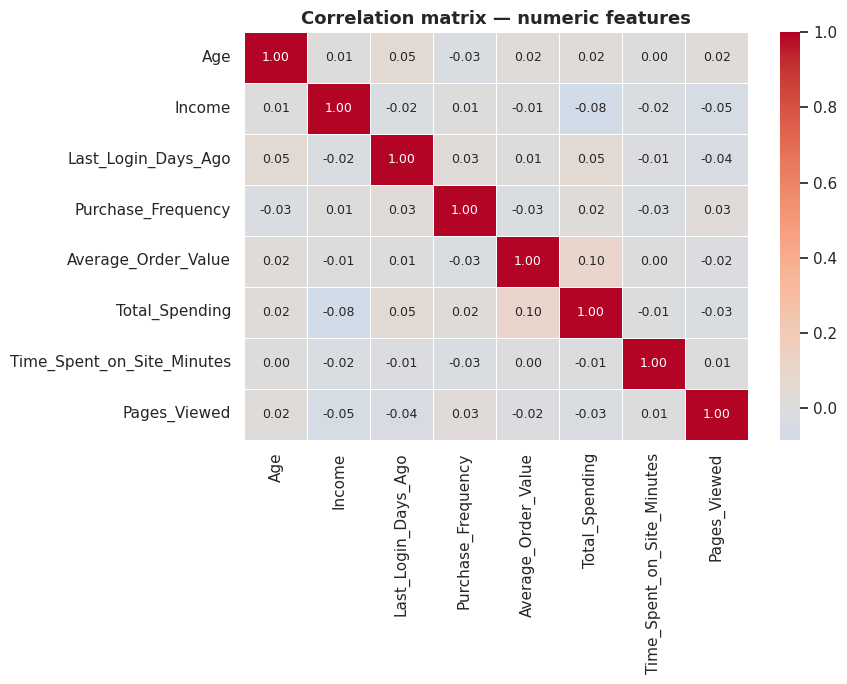

correlation_heatmap.


In [12]:

print("\n" + "=" * 60)
print("SECTION 3 — PURCHASE PATTERNS")
print("=" * 60)

freq_seg   = df["freq_segment"].value_counts().sort_index()
interests  = df["Interests"].value_counts()
newsletter = df.groupby("Newsletter_Subscription")["Total_Spending"].mean().round(2)

print(f"\nPurchase frequency distribution:\n{df['Purchase_Frequency'].describe().round(2)}")
print(f"\nFrequency segments:\n{freq_seg}")
print(f"\nTop interests:\n{interests}")
print(f"\nAvg spending by newsletter subscription:\n{newsletter}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Purchase Patterns", fontsize=14, fontweight="bold")

# Frequency distribution — histogram
axes[0].hist(df["Purchase_Frequency"], bins=10, color="#7F77DD", edgecolor="white")
axes[0].set_title("Purchase frequency distribution")
axes[0].set_xlabel("Purchase frequency")
axes[0].set_ylabel("User count")

# Frequency segments — donut
seg_colors = ["#1D9E75", "#378ADD", "#F0997B"]
axes[1].pie(freq_seg.values, labels=freq_seg.index, autopct="%1.1f%%",
            colors=seg_colors, startangle=140, pctdistance=0.82,
            wedgeprops=dict(width=0.55))
axes[1].set_title("Purchase frequency segments")

# Interests bar
axes[2].bar(interests.index, interests.values, color=PALETTE, edgecolor="white")
axes[2].set_title("Top user interests")
axes[2].set_xlabel("Interest")
axes[2].set_ylabel("User count")
axes[2].tick_params(axis="x", rotation=20)
for bar, val in zip(axes[2].patches, interests.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
#plt.savefig("plot3_purchase_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("purchase_patterns")

# ── Newsletter vs spending ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No newsletter", "Newsletter"], newsletter.values,
       color=["#D4537E", "#1D9E75"], edgecolor="white", width=0.5)
ax.set_title("Avg total spending — newsletter subscribers vs non-subscribers")
ax.set_ylabel("Avg total spending (₹)")
for bar, val in zip(ax.patches, newsletter.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"₹{val:,.2f}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
#plt.savefig("plot4_newsletter_spending.png", dpi=150, bbox_inches="tight")
plt.show()
print("newsletter_spending")

# ── Correlation heatmap ───────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CORRELATION HEATMAP — NUMERIC FEATURES")
print("=" * 60)

numeric_cols = ["Age", "Income", "Last_Login_Days_Ago", "Purchase_Frequency",
                "Average_Order_Value", "Total_Spending",
                "Time_Spent_on_Site_Minutes", "Pages_Viewed"]
corr = df[numeric_cols].corr()
print(corr.round(2))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Correlation matrix — numeric features", fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("plot5_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("correlation_heatmap.")
